# VoicePilot
__Short description__
The goal is to be able to use simple voice commands like “down”, “up”, “left”, and other keywords for different keybinds, where ultimately the model can be used on different games with similar inputs.

**Neste møte:**
- Lag en mindre modell
- Kanskje bruk "mini_speech_commands"

In [23]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

Last ned og inspiser datasettet

In [2]:
DATASET_PATH = 'data/mini_speech_commands'

data_dir = pathlib.Path(DATASET_PATH)
if not data_dir.exists():
    tf.keras.utils.get_file(
        'mini_speech_commands.zip',
        origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
        extract=True,
        cache_dir='.', cache_subdir='data')

In [3]:
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands = commands[(commands != 'README.md') & (commands != '.DS_Store')]
print('Commands:', commands)

Commands: ['right' 'go' 'no' 'down' 'stop' 'left' 'up' 'yes']


Gjør datasettet om til `tf.data.Dataset` og splitt det opp i trening- og valiseringssett

In [4]:
(train_ds, val_ds) = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=42,
    output_sequence_length=16000,
    subset='both'
)

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)

Found 8000 files belonging to 8 classes.
Using 6400 files for training.
Using 1600 files for validation.

label names: ['down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']


2026-03-17 13:59:25.088809: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
def squeeze(audio, labels):
    audio = tf.squeeze(audio, axis=-1)
    return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

Siden `tf.keras.utils.audio_dataset_from_directory` bare gir train og validation splits, må vi lage en ny split for testing. Dette kan vi gjøre med `tf.data.Dataset.shard`. `num_shards` forteller tensorflow at datasettet skal deles i to like store deler, `index` forteller hvilke av de to delene den skal hente dataen fra.

In [6]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [7]:
for example_audio, example_labels in train_ds.take(1):
    print(example_audio.shape)
    print(example_labels.shape)

(64, 16000)
(64,)


2026-03-17 13:59:25.246964: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
print(label_names[example_labels])

['up' 'yes' 'up' 'go' 'down' 'down' 'down' 'up' 'down' 'no' 'right' 'down'
 'up' 'down' 'left' 'stop' 'up' 'stop' 'yes' 'yes' 'left' 'go' 'stop'
 'yes' 'up' 'right' 'no' 'down' 'go' 'stop' 'right' 'go' 'yes' 'no' 'stop'
 'no' 'up' 'no' 'go' 'yes' 'no' 'right' 'up' 'yes' 'go' 'go' 'no' 'go'
 'yes' 'go' 'up' 'right' 'go' 'go' 'go' 'go' 'go' 'right' 'stop' 'stop'
 'stop' 'go' 'up' 'yes']


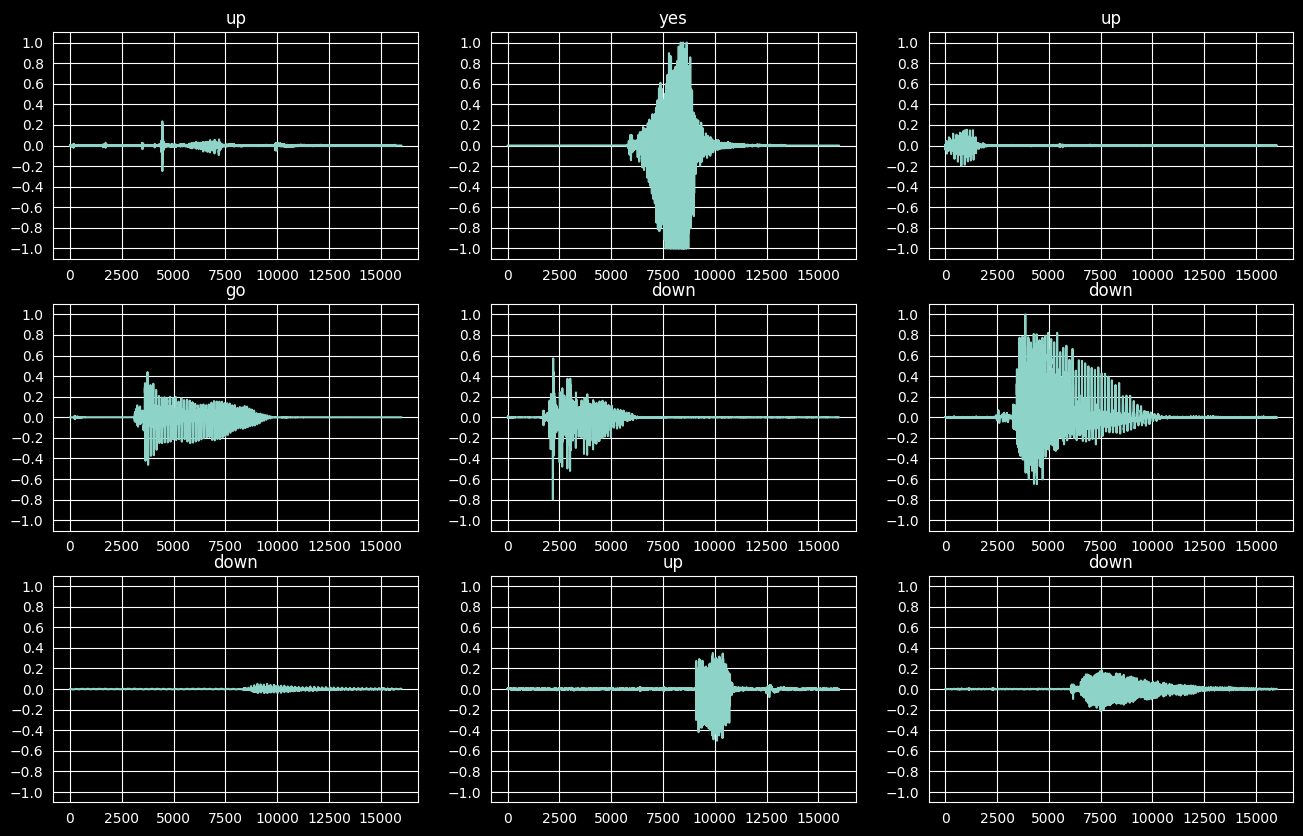

In [9]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
    plt.subplot(rows, cols, i+1)
    audio_signal = example_audio[i]
    plt.plot(audio_signal)
    plt.title(label_names[example_labels[i]])
    plt.yticks(np.arange(-1.2, 1.2, 0.2))
    plt.ylim([-1.1, 1.1])

First we will try to make create a model on the raw spectograms.

In [16]:
# Definer model strukturen
model = models.Sequential([
    layers.Input(shape=(16000,1)),

    # Downsample the audio (16kHz is a lot of data)
    # layers.Resizing(32, 500), # Optional: shrinks the data to speed up training

    layers.Conv1D(64, 3, activation='relu'),
    layers.MaxPooling1D(),

    layers.Conv1D(128, 3, activation='relu'),
    layers.MaxPooling1D(),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(8, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 15998, 64)      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 7999, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 7997, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 3998, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3998, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 511744)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │    65,503,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,529,352 (249.97 MB)

 Trainable params: 65,529,352 (249.97 MB)

 Non-trainable params: 0 (0.00 B)

Tren og kompiler modellen

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy,
    metrics=["accuracy"]
)

train_ds_expanded = train_ds.map(lambda x, y: (tf.expand_dims(x, axis=-1), y))
val_ds_expanded = val_ds.map(lambda x, y: (tf.expand_dims(x, axis=-1), y))

epochs = 10
history = model.fit(
    train_ds_expanded,
    validation_data=val_ds_expanded,
    epochs=epochs
)

Epoch 1/10
  4/100 ━━━━━━━━━━━━━━━━━━━━ 1:16 801ms/step - accuracy: 0.1419 - loss: 2.1197

KeyboardInterrupt: 

Når vi ser på epochene, er det ganske tydelig at modellen overfittet ganske mye, dette ser vi på forskjellen mellom accuracy og loss på treningssettet og valideringssettet. Men la oss teste modellen på testsettet uansett.

In [18]:
test_ds_expanded = test_ds.map(lambda x, y: (tf.expand_dims(x, axis=-1), y))
test_loss, test_acc = model.evaluate(test_ds_expanded)

print(f"\nTest Accuracy: {test_acc:.2%}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.1935 - loss: 2.0687

Test Accuracy: 19.35%


Vi ser at modellen gjør det ganske dårlig på ny data, dette stemmer med at modellen overfitter.

# Spectograms

Denne gangen skal vi gjøre om lyddataen til spektogrammer. Dette gjør vi ved hjelp av short-time Fourier Transormation (STFT) algoritmen

In [19]:
def get_spectrogram(waveform):
    # Convert the waveform to a spectrogram via a STFT.
    spectrogram = tf.signal.stft(
        waveform, frame_length=255, frame_step=128)
    # Obtain the magnitude of the STFT.
    spectrogram = tf.abs(spectrogram)
    # Add a `channels` dimension, so that the spectrogram can be used
    # as image-like input data with convolution layers (which expect
    # shape (`batch_size`, `height`, `width`, `channels`).
    spectrogram = spectrogram[..., tf.newaxis]
    return spectrogram


Nå kan vi se på dataen som spectogrammer

In [24]:
for i in range(3):
    label = label_names[example_labels[i]]
    waveform = example_audio[i]
    spectrogram = get_spectrogram(waveform)

    print('Label:', label)
    print('Waveform shape:', waveform.shape)
    print('Spectrogram shape:', spectrogram.shape)
    print('Audio playback')
    display.display(display.Audio(waveform, rate=16000))

Label: up
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: yes
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: up
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


In [25]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

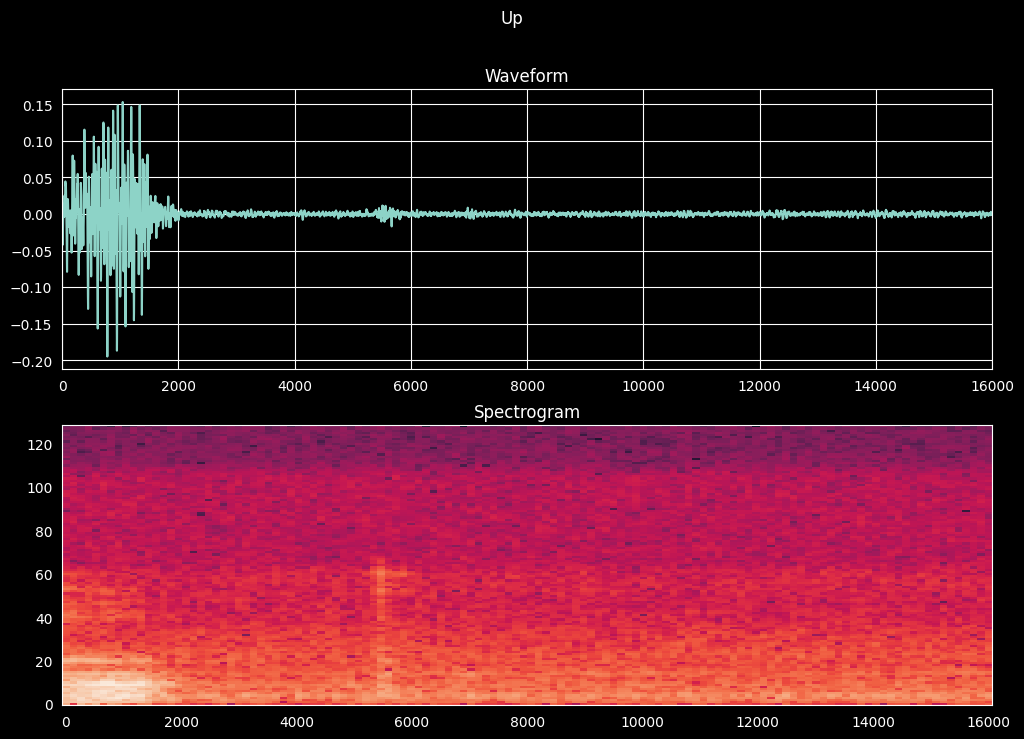

In [26]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()


Nå kan vi lage nye dataset som inneholder lydfilene som spektogrammer

In [28]:
# Hjelpefunksjon
def make_spec_ds(ds: tf.data.Dataset):
    return ds.map(
        map_func=lambda audio, label: (get_spectrogram(audio), label),
        num_parallel_calls=tf.data.AUTOTUNE)


In [29]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

In [30]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

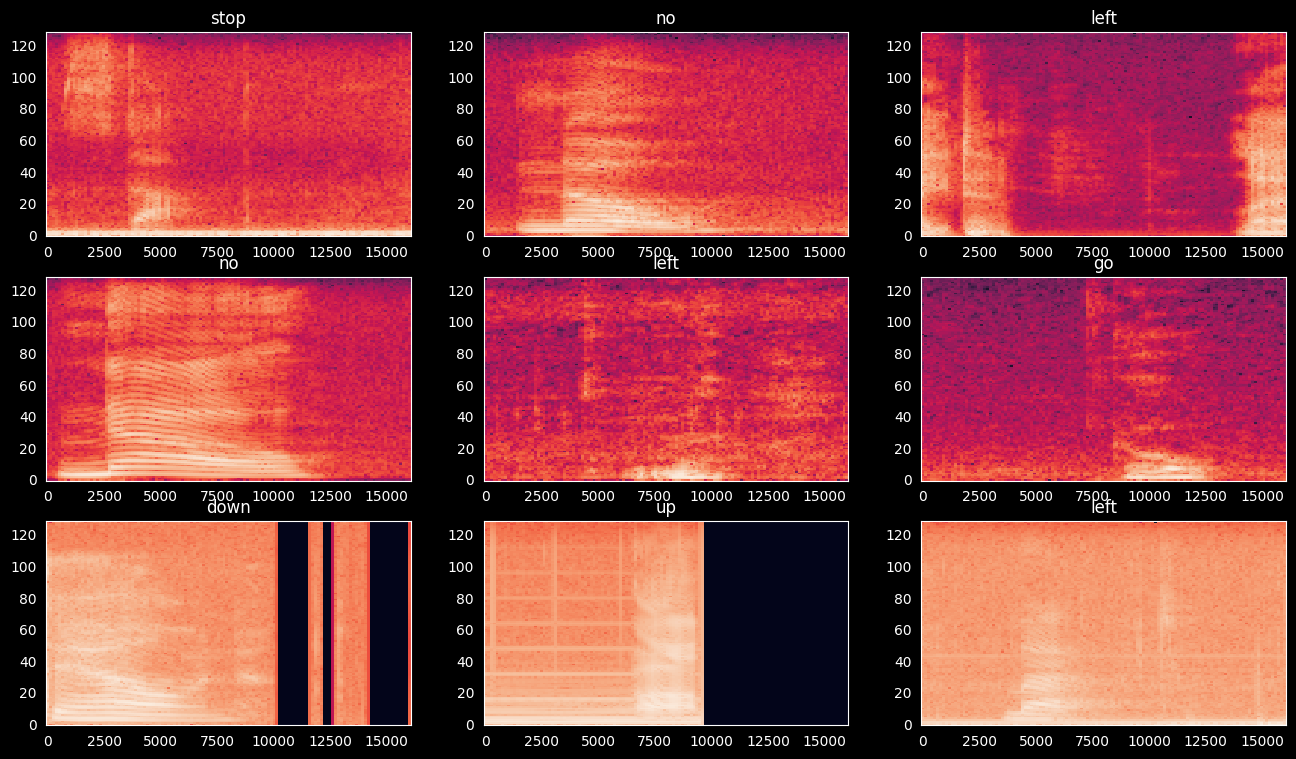

In [31]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

Vi kan bruke `Dataset.cache()` og `Dataset.prefetch()` for å optimalisere treningstiden

In [33]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)


In [34]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (124, 129, 1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_2 (Resizing)           │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,611 (6.20 MB)

 Trainable params: 1,625,608 (6.20 MB)

 Non-trainable params: 3 (16.00 B)

Konfigurer modellen med adam optimizer og cross-entropy loss-funksjon

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

Tren modellen

In [36]:
EPOCHS = 10
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3664 - loss: 1.7493 - val_accuracy: 0.5404 - val_loss: 1.3731
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5813 - loss: 1.1636 - val_accuracy: 0.6562 - val_loss: 0.9576
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6837 - loss: 0.8842 - val_accuracy: 0.7461 - val_loss: 0.7621
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7280 - loss: 0.7485 - val_accuracy: 0.7461 - val_loss: 0.7009
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7869 - loss: 0.6058 - val_accuracy: 0.7865 - val_loss: 0.6278
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7991 - loss: 0.5559 - val_accuracy: 0.8060 - val_loss: 0.5948
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8305 - loss: 0.4885 - val_accuracy: 0.7995 - val_loss: 0.5452
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8472 - loss: 0.4371 - val_accu

Vi kan plotte loss kurvene for å se hvordan modellen ble bedre under trening

Text(0, 0.5, 'Accuracy [%]')

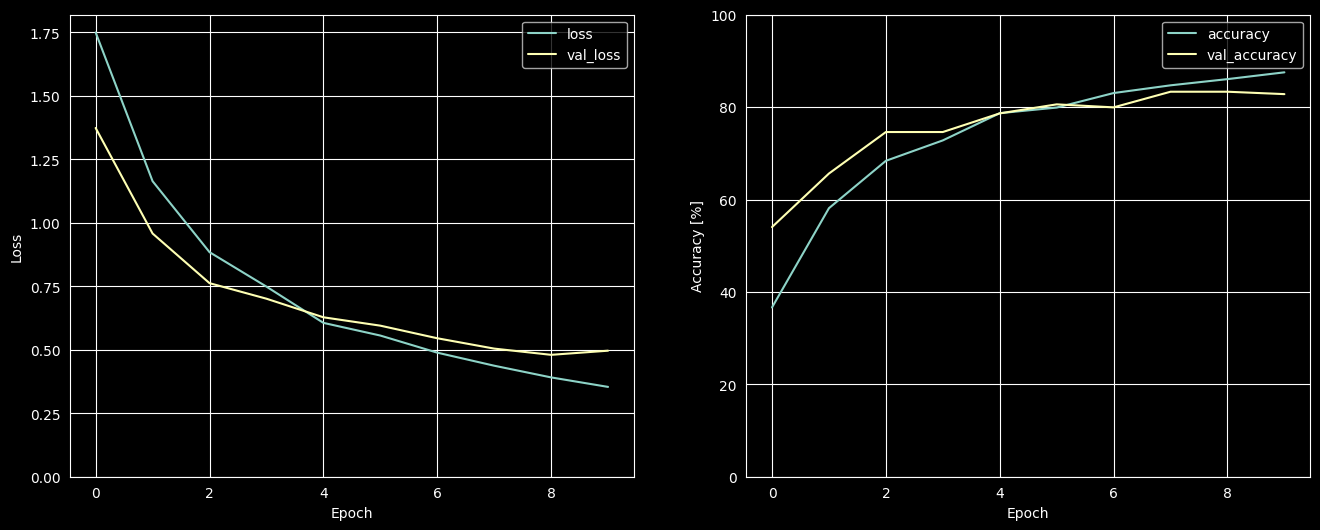

In [38]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')


Nå kan vi kjøre modellen på testsettet for å sjekke hvor god den er

In [42]:
test_loss, test_acc = model.evaluate(test_spectrogram_ds, verbose=2)

print(f'\nTest accuracy: {test_acc:.2%}')

13/13 - 0s - 12ms/step - accuracy: 0.8413 - loss: 0.5662

Test accuracy: 84.13%


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


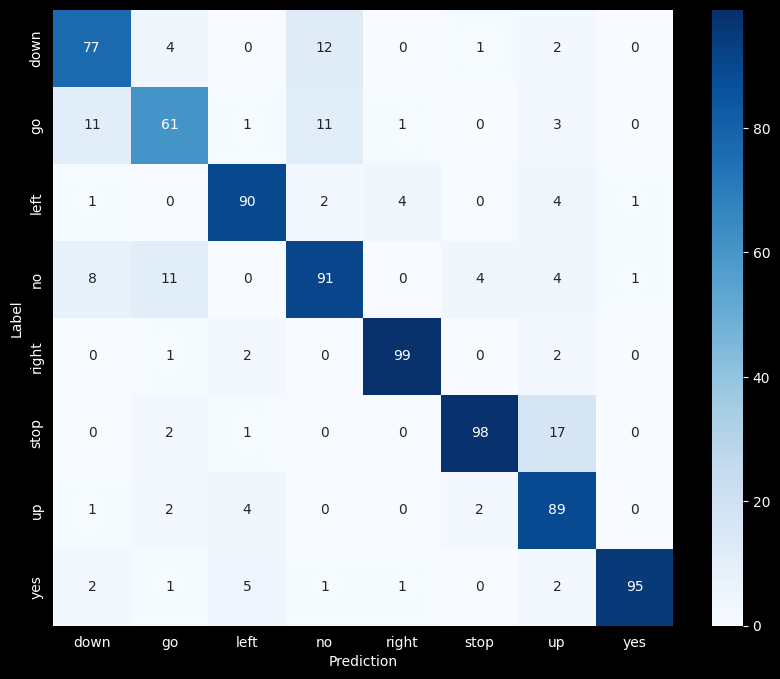

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = []
y_true = []

for audio, label in test_spectrogram_ds:
    prediction = model.predict(audio)
    y_pred.extend(np.argmax(prediction, axis=1))
    y_true.extend(label.numpy())

# Create the matrix
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, xticklabels=label_names, yticklabels=label_names,
            annot=True, fmt='g', cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

Vi kan også teste modellen på en lydfil, for å se hvor bra den virker på et ekte eksempel

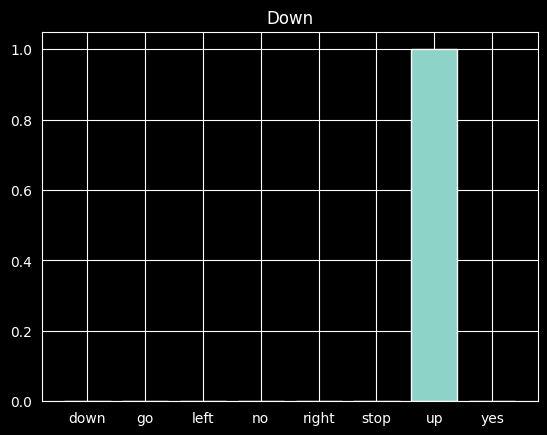

In [49]:
x = data_dir/'up/0ac15fe9_nohash_0.wav'
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000)
x = tf.squeeze(x, axis=-1)
waveform = x
x = get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
plt.bar(label_names, tf.nn.softmax(prediction[0])) # Use the list generated by the dataset
plt.title('Up')
plt.show()

display.display(display.Audio(waveform, rate=16000))

Save the model

In [51]:
model.save('mini_speech_model.keras')